## Helpers

In [469]:
import torch
import seaborn as sns

# set seed
torch.manual_seed(42)
sns.set_theme()
sns.set_palette("colorblind")

def interference_ds(a1, a2, x):
    """Computes interference E_x[||a1x - a2x||]
    
    Args:
        a1, a2 (torch.Tensor): (D,D)
        x (torch.Tensor): (N, D)

    Returns:
        float: interference
    """
    if a1.ndim == 1:
        a1 = a1.unsqueeze(0)
    if a2.ndim == 1:
        a2 = a2.unsqueeze(0)
    diff = a1 @ x.T - a2 @ x.T  # shape (D, N)
    return torch.linalg.norm(diff, dim=0).mean().item()

# For debugging
def interference_abs(a1, a2, x):
    """Computes interference E_x[||a1x - a2x||]
    
    Args:
        a1, a2 (torch.Tensor): (D)
        x (torch.Tensor): (N, D)

    Returns:
        float: interference
    """
    assert a1.ndim == 1 and a2.ndim == 1, "a1 and a2 must be 1D"
    diffs = (a1 - a2) @ x.T  # shape (N,)
    return diffs.abs().mean().item()

def rot2d(theta: float) -> torch.Tensor:
    # Only supports 2D rotation
    tt = torch.tensor(theta)
    return torch.tensor([
        [torch.cos(tt), -torch.sin(tt)],
        [torch.sin(tt),  torch.cos(tt)]
    ])

def create_datasets_and_task_vectors_2d(theta, sigma_perturb=0.05, sigma_scale=0.1, n_samples=1000, t0idx=-1):
    # thetas is a list of angles
    t0 = torch.eye(2)[t0idx]
    t1 = rot2d(theta) @ t0
    task_vectors = torch.stack([t0, t1], dim=0) # (N, D) = (2, 2)
    task_vectors = task_vectors / torch.linalg.norm(task_vectors, dim=1, keepdim=True)
    n_tasks, d_task = task_vectors.shape[0], task_vectors.shape[1]
    x_tasks = task_vectors + torch.randn(n_samples, n_tasks, d_task) * sigma_perturb
    x_tasks = x_tasks * (1.0 + torch.randn(n_samples, n_tasks, 1) * sigma_scale)
    return x_tasks, task_vectors


def create_datasets_and_task_vectors(n_tasks=3, d_task=32, sigma_perturb=0.05, sigma_scale=0.1, n_samples=1000):
    task_vectors = torch.randn(n_tasks, d_task)
    task_vectors = task_vectors / torch.linalg.norm(task_vectors, dim=1, keepdim=True)
    x_tasks = task_vectors + torch.randn(n_samples, n_tasks, d_task) * sigma_perturb
    # random scaling but same direction
    x_tasks = x_tasks * (1.0 + torch.randn(n_samples, n_tasks, 1) * sigma_scale)
    return x_tasks, task_vectors


def compute_procrustes(x: torch.Tensor) -> torch.Tensor:
    """Finds best ortho approx of x

    Args:
        x (torch.Tensor): (Di, Do)

    Returns:
        torch.Tensor: (Di, Do)
    """
    u, _, vt = torch.linalg.svd(x, full_matrices=False)
    return u @ vt


def cos_sim(a, b):
    a, b = a.flatten(), b.flatten()
    return a.T @ b / (torch.linalg.norm(a) * torch.linalg.norm(b))

## Synthetic Data

### TSV Multi-Task Interference

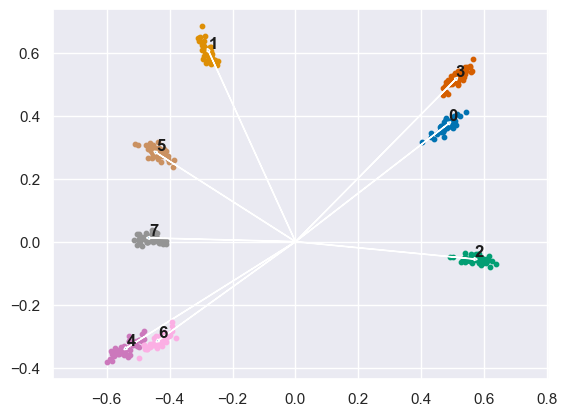

In [459]:
import torch
import matplotlib.pyplot as plt

# set seed
torch.manual_seed(42)

x, tvs = create_datasets_and_task_vectors(n_tasks=8, d_task=8, sigma_perturb=0.01, sigma_scale=0.05, n_samples=50)
for i in range(tvs.shape[0]):
    plt.scatter(x[:,i,0], x[:,i,1], s=10)
    plt.arrow(0, 0, tvs[i,0], tvs[i,1], head_width=0.01, head_length=0.01)
    plt.text(tvs[i,0], tvs[i,1], f"{i}", fontsize=12, color='k', ha='left', va='bottom', fontweight='bold')
plt.axis('equal')
plt.show()


/var/folders/r_/d81gvkws1n5fg2_7mb57cwzh0000gn/T/ipykernel_83510/1177270864.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_interference, x='Method', y='Interference', ax=ax2, palette=palette, order=method_order, dodge=False)


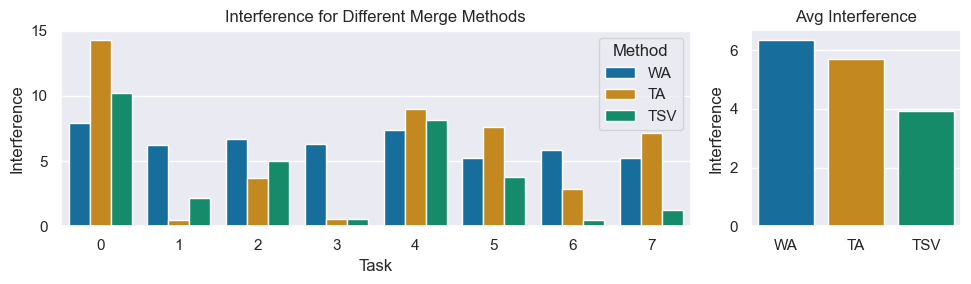

In [460]:
# Compute interference for different merge methods
import seaborn as sns
import pandas as pd

def interference_ds(a1, a2, x):
    """Computes interference E_x[||a1x - a2x||], where x ~ N(0, I)."""
    diff = a1 @ x.T - a2 @ x.T  # shape (D, N)
    norm = torch.linalg.norm(diff, dim=0)  # shape (N,)
    return norm.mean().item()

w_ta = tvs.sum(dim=0)     # (D,)
w_wa = tvs.mean(dim=0)    # (D,)
w_tsv = compute_procrustes(tvs.T).T.sum(dim=0)
n_tasks = tvs.shape[0]

data = []
for t in range(n_tasks):
    data.append({'Task': t, 'Method': 'WA', 'Interference': interference_ds(w_wa, tvs[t], x[:,t])})
    data.append({'Task': t, 'Method': 'TA', 'Interference': interference_ds(w_ta, tvs[t], x[:,t])})
    data.append({'Task': t, 'Method': 'TSV', 'Interference': interference_ds(w_tsv, tvs[t], x[:,t])})
df = pd.DataFrame(data)

# Compute average interference for each method
avg_interference = df.groupby('Method')['Interference'].mean().reset_index()

# Specify a consistent palette for both plots, matching the order of methods
method_order = ['WA', 'TA', 'TSV']
palette = dict(zip(method_order, sns.color_palette("colorblind", n_colors=len(method_order))))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,3), width_ratios=[3,1])

sns.barplot(data=df, x='Task', y='Interference', hue='Method', ax=ax1, palette=palette, hue_order=method_order)
ax1.set(title="Interference for Different Merge Methods", xlabel='Task', ylabel='Interference')

sns.barplot(data=avg_interference, x='Method', y='Interference', ax=ax2, palette=palette, order=method_order, dodge=False)
ax2.set(title="Avg Interference", ylabel='Interference', xlabel='')

plt.tight_layout()
plt.show()

<Axes: >

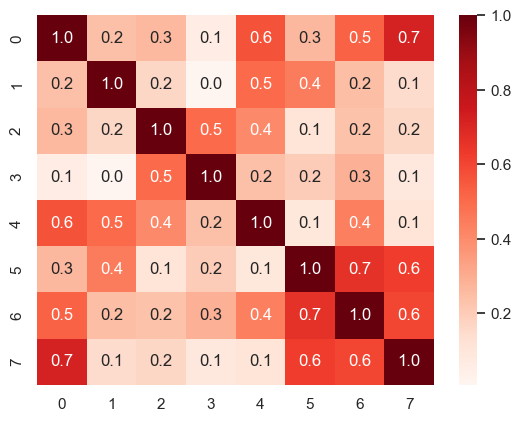

In [461]:
# Compute the proper cosine similarity matrix between all pairs of task vectors
tvs_norm = tvs / tvs.norm(dim=1, keepdim=True)  # (n_tasks, D)
cosim = tvs_norm @ tvs_norm.T  # (n_tasks, n_tasks)
cosim = cosim.abs()

# Use a perceptually uniform palette for the heatmap (cmap="viridis" or "mako")
sns.heatmap(
    cosim.cpu().numpy(), 
    fmt=".1f", 
    cbar=True, 
    cmap="Reds",    # Try 'mako', 'viridis', or 'rocket' for a better palette
    annot=True      # Optional: show values
)

### TSV 2-Task Partial Interference Sweep -- Vector

/var/folders/r_/d81gvkws1n5fg2_7mb57cwzh0000gn/T/ipykernel_83510/191752648.py:28: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  tt = torch.tensor(theta)


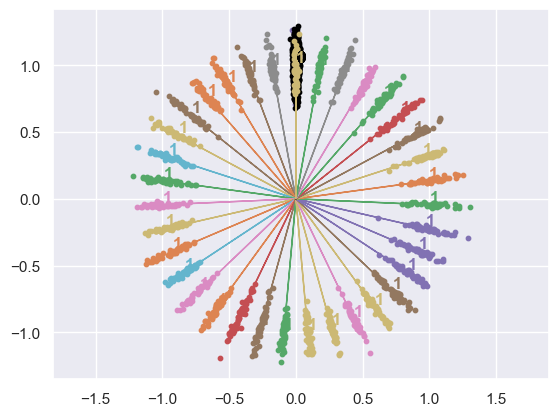

In [462]:
import torch
import math
import matplotlib.pyplot as plt
import random
sns.set_theme()

exps = []
for idx, theta_v in enumerate(torch.linspace(0, math.pi*2, steps=36)):
    x, tvs = create_datasets_and_task_vectors_2d(theta_v, sigma_perturb=0.01, sigma_scale=0.1, n_samples=50)
    exps.append((x, tvs, theta_v))
    for t in range(2):
        color = 'black' if t == 0 else random.choice(['C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9'])
        plt.scatter(x[:,t,0], x[:,t,1], s=10, color=color, label=f'Task {t}' if idx == 0 else None)
        plt.arrow(0, 0, tvs[t,0], tvs[t,1], head_width=0.01, head_length=0.01, color=color)
        plt.text(tvs[t,0], tvs[t,1], f"{t}", fontsize=12, color=color, ha='left', va='bottom', fontweight='bold')
plt.axis('equal')
plt.show()


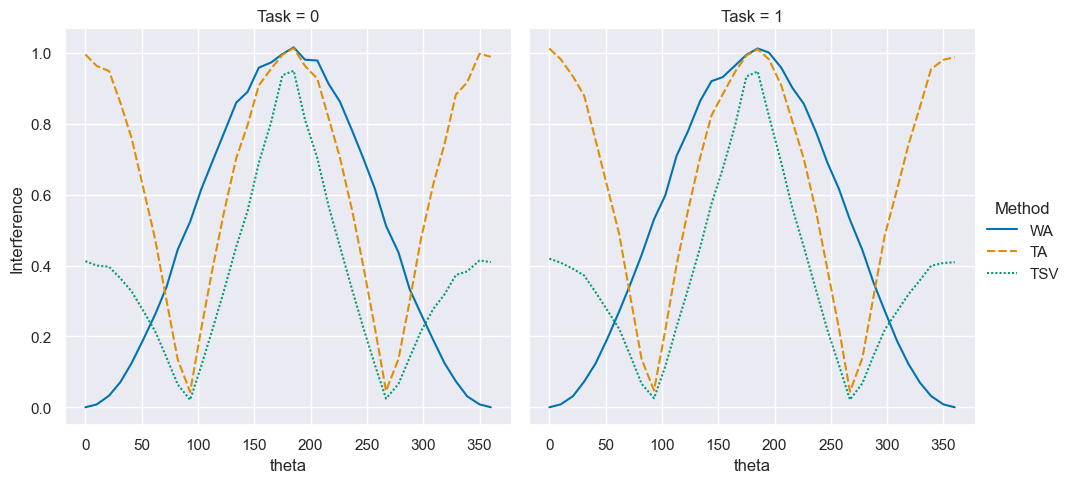

In [475]:
# Compute interference for different merge methods
import seaborn as sns
import pandas as pd

data = []
for x, tvs, theta_v in exps:
    w_ta = tvs.sum(dim=0)     # (D,)
    w_wa = tvs.mean(dim=0)    # (D,)
    w_tsv = compute_procrustes(tvs.T).T.sum(dim=0)
    n_tasks = tvs.shape[0]
    theta_deg = torch.round(theta_v * 180 / math.pi).item()
    for t in range(n_tasks):
        data.append({'Task': t, 'Method': 'WA', 'Interference': interference_abs(w_wa, tvs[t], x[:,t]), 'theta': theta_deg})
        data.append({'Task': t, 'Method': 'TA', 'Interference': interference_abs(w_ta, tvs[t], x[:,t]), 'theta': theta_deg})
        data.append({'Task': t, 'Method': 'TSV', 'Interference': interference_abs(w_tsv, tvs[t], x[:,t]), 'theta': theta_deg})
df = pd.DataFrame(data)

# Emphasize TSV in palette and marker
sns.relplot(data=df, x='theta', y='Interference', hue='Method', kind='line', col='Task', style="Method")


### TSV 2-Task Partial Interference Sweep -- Matrix


Angle (degrees): 0.00
ta error: 1.00, 1.00
wa error: 0.00, 0.00
tsv error: 0.00, 0.00

Angle (degrees): 30.00
ta error: 0.87, 0.87
wa error: 0.07, 0.07
tsv error: 0.26, 0.26

Angle (degrees): 60.00
ta error: 0.50, 0.50
wa error: 0.25, 0.25
tsv error: 0.52, 0.52

Angle (degrees): 90.00
ta error: 0.00, 0.00
wa error: 0.50, 0.50
tsv error: 0.77, 0.77

Angle (degrees): 120.00
ta error: 0.50, 0.50
wa error: 0.75, 0.75
tsv error: 1.00, 1.00

Angle (degrees): 150.00
ta error: 0.87, 0.87
wa error: 0.93, 0.93
tsv error: 1.22, 1.22

Angle (degrees): 180.00
ta error: 1.00, 1.00
wa error: 1.00, 1.00
tsv error: 1.41, 1.41

Angle (degrees): 210.00
ta error: 0.87, 0.87
wa error: 0.93, 0.93
tsv error: 1.22, 1.22

Angle (degrees): 240.00
ta error: 0.50, 0.50
wa error: 0.75, 0.75
tsv error: 1.00, 1.00

Angle (degrees): 270.00
ta error: 0.00, 0.00
wa error: 0.50, 0.50
tsv error: 0.77, 0.77

Angle (degrees): 300.00
ta error: 0.50, 0.50
wa error: 0.25, 0.25
tsv error: 0.52, 0.52

Angle (degrees): 330.00
t

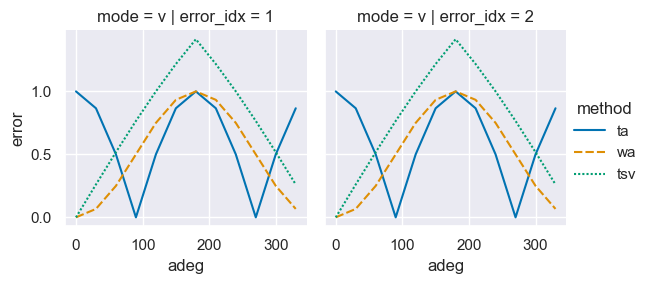

In [480]:
def get_projector_interference(theta_deg, verbose=False, mode='v', sigma_perturb=0.00, sigma_scale=0.0):
    theta_rads = theta_deg/360 * 2*math.pi  
    if mode == 'v':
        x, vs = create_datasets_and_task_vectors_2d(theta_rads, sigma_perturb=sigma_perturb, sigma_scale=sigma_scale, n_samples=50, t0idx=0)
        u = torch.eye(2)[-1]
        u1, u2 = u, u
        v1, v2 = vs[0], vs[1]
    else:
        _, us = create_datasets_and_task_vectors_2d(theta_rads, sigma_perturb=sigma_perturb, sigma_scale=sigma_scale, n_samples=50, t0idx=0)
        x, vs = create_datasets_and_task_vectors_2d(0, sigma_perturb=sigma_perturb, sigma_scale=sigma_scale, n_samples=50, t0idx=-1)
        u1, u2 = us[0], us[1]
        v1, v2 = vs[0], vs[1]

    uorth = compute_procrustes(torch.stack([u1, u2], dim=1)).T
    vorth = compute_procrustes(torch.stack([v1, v2], dim=1)).T

    u1o, u2o = uorth[0], uorth[1]
    v1o, v2o = vorth[0], vorth[1]

    w_targ_1 = torch.einsum('i,j->ij', u1, v1)
    w_targ_2 = torch.einsum('i,j->ij', u2, v2)
    w_ta = torch.einsum('i,j->ij', u1, v1) + torch.einsum('i,j->ij', u2, v2)
    w_wa = 1/2 * w_ta
    w_tsv = torch.einsum('i,j->ij', u1o, v1o) + torch.einsum('i,j->ij', u2o, v2o)


    if verbose:
        print(f"\nAngle (degrees): {theta_rads * 180 / math.pi:.2f}")
    errors_1 = {}
    errors_2 = {}
    for w, name in zip([w_ta, w_wa, w_tsv], ['ta', 'wa', 'tsv']):
        y_hat1 = w @ x[:, 0].T  # [D, N]
        y_hat2 = w @ x[:, 1].T  # [D, N]
        y1 = w_targ_1 @ x[:, 0].T  # [D, N]
        y2 = w_targ_2 @ x[:, 1].T  # [D, N]
        diff_1 = y1 - y_hat1
        diff_2 = y2 - y_hat2    
        # error_1 = diff_1.abs().mean().item()
        # error_2 = diff_2.abs().mean().item()
        error_1 = torch.linalg.norm(diff_1, dim=0).mean().item() # [D, D] @ [D, N] -> [D, N]
        error_2 = torch.linalg.norm(diff_2, dim=0).mean().item() # [D, D] @ [D, N] -> [D, N]
        errors_1[name] = error_1
        errors_2[name] = error_2
        if verbose:
            print(f"{name} error: {error_1:.2f}, {error_2:.2f}")
    return errors_1, errors_2


rows = []
for mode in ['v']:
    for adeg in range(0, 360, 30):
        # adeg = adeg.item()
        errors_1, errors_2 = get_projector_interference(adeg, mode=mode, verbose=True)
        rows.extend([
            {'adeg': adeg, 'method': 'ta', 'error': errors_1['ta'], 'error_idx': 1, 'mode': mode},
            {'adeg': adeg, 'method': 'wa', 'error': errors_1['wa'], 'error_idx': 1, 'mode': mode},
            {'adeg': adeg, 'method': 'tsv', 'error': errors_1['tsv'], 'error_idx': 1, 'mode': mode},
            {'adeg': adeg, 'method': 'ta', 'error': errors_2['ta'], 'error_idx': 2, 'mode': mode},
            {'adeg': adeg, 'method': 'wa', 'error': errors_2['wa'], 'error_idx': 2, 'mode': mode}, 
            {'adeg': adeg, 'method': 'tsv', 'error': errors_2['tsv'], 'error_idx': 2, 'mode': mode},
        ])

# Plot the errors for both error_idx values side by side using seaborn
df = pd.DataFrame(rows)
sns.relplot(data=df, x='adeg', y='error', style='method', hue='method', col='error_idx', row='mode', kind='line', height=3, aspect=1)



## Real Data

In [89]:
# Load model for Cars
import torch
import certifi
import os
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

from src.datasets.registry import get_dataset
from src.datasets.common import get_dataloader_v2, maybe_dictionarize
from src.models.modeling import ImageClassifier, ImageEncoder
from src.models.heads import build_classification_head
from src.datasets.templates import get_templates

os.environ['SSL_CERT_FILE'] = certifi.where()

dataset_name = "CIFAR10"
batch_size = 32
template = get_templates(dataset_name)
data_location = "datasets"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_name = "ViT-B-16"

# Build model
image_encoder = ImageEncoder(model_name, keep_lang=True)

classification_head = build_classification_head(image_encoder.model, dataset_name, template, data_location, device)
model = ImageClassifier(image_encoder, classification_head)

dataset_name = "CIFAR10"
batch_size = 1
dataset = get_dataset(
    dataset_name,
    model.val_preprocess,
    location=data_location,
    batch_size=batch_size,
)
dataloader = get_dataloader_v2(dataset, is_train=False, image_encoder=None, batch_size=batch_size, device=device)

/Users/marawangamal/Documents/github/task_singular_vectors/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/marawangamal/Documents/github/task_singular_vectors/.venv/lib/python3.10/site-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(
100%|██████████| 170M/170M [00:12<00:00, 13.6MB/s] 


Building classification head.


100%|██████████| 10/10 [00:01<00:00,  6.78it/s]


zeroshot shape, Ptorch.Size([10, 512])


In [91]:
dataloader = get_dataloader_v2(dataset, is_train=False, image_encoder=None, batch_size=1, device=device)

In [92]:
# Need to save mats (T, Do, Di) and acts (T, N, Do)
# Pass single batch and measure mean and std of all activations
data = maybe_dictionarize(next(iter(dataloader)))
x = data['images']
out = model(x)
out.shape
# >>> out.shape
# torch.Size([32, 1000])

torch.Size([32, 10])

## MISC

MISC

In [ ]:

# *** Helpers OLD
def interference_old(a1, a2, n_points=10_000, batch_size=100):
    """Computes interference E_x[||a1x - a2x||], where x ~ N(0, I).

    Args:
        a1 (torch.Tensor): (Do, Di)
        a2 (torch.Tensor): (Do, Di)
        n_points (int, optional): Number of points to sample. Defaults to 10_000.
        batch_size (int, optional): Batch size for sampling. Defaults to 100.

    Returns:
        float: Interference.
    """
    total = 0.0
    device = a1.device
    Do, Di = a1.shape
    n_batches = n_points // batch_size
    for _ in range(n_batches):
        x = torch.randn(batch_size, Di, device=device)
        diff = a1 @ x.T - a2 @ x.T  # shape (Do, batch_size)
        norm = torch.linalg.norm(diff, dim=0)  # shape (batch_size,)
        total += norm.sum().item()
    return total / (n_batches * batch_size)

def merge_tsv(tensors, *args, **kwargs):
    """Computes the TSV merge of the given tensors.

    Args:
        tensors (torch.Tensor): The tensors to merge. Shape: (N_tasks, Di, Do)

    Returns:
        torch.Tensor: The merged tensors. Shape: (Di, Do)
    """
    N_tasks = len(tensors)
    u, s, vt = torch.linalg.svd(tensors, full_matrices=False)
    R = min(u.shape[1], vt.shape[2])
    Rp = R // N_tasks
    u, s, vt = u[:, :, :Rp], s[:, :Rp], vt[:, :Rp, :]

    # # # w/o decorrelation
    # tau_bl = torch.einsum("bij,bj,bjk->bik", u, s, vt)
    # tau[layer_name] = tau_bl.sum(dim=0)

    # w/ decorrelation
    B, Di, _ = u.shape
    _, _, Do = vt.shape
    # (Di, B, R)
    u_hat = u.permute(1, 0, 2).reshape(Di, B * Rp)
    s_hat = s.reshape(-1)
    vt_hat = vt.reshape(B * Rp, Do)
    u_ortho = compute_procrustes(u_hat)  # (Di, Rp)
    vt_ortho = compute_procrustes(vt_hat.T).T  # (Rp, Do)
    tau_l = torch.einsum("ij,j,jk->ik", u_ortho, s_hat, vt_ortho)
    return tau_l



import matplotlib.pyplot as plt

v = torch.randn(2, 1)
v = v / torch.linalg.norm(v)
V = torch.cat([v, v], dim=1)  # (2, 2)
Vortho = compute_procrustes(V)
v_recons = 1/2 * Vortho.sum(dim=1, keepdim=True)  # (2, 1)

plt.figure(figsize=(6, 6))
plt.quiver([0, 0], [0, 0], V[0], V[1], angles='xy', scale_units='xy', scale=1, color=['b', 'b'], label='Original V')
plt.quiver([0, 0], [0, 0], Vortho[0], Vortho[1], angles='xy', scale_units='xy', scale=1, color=['r', 'r'], label='Ortho V')
plt.quiver([0], [0], v_recons[0], v_recons[1], angles='xy', scale_units='xy', scale=1, color=['g'], label='Reconstructed v')
plt.xlim(-2, 2)
plt.ylim(-2, 2)
plt.grid()
plt.title('V before (blue), after (red) Procrustes, and v_recons (green)')
plt.legend(['Original V', 'Ortho V', 'Reconstructed v'])
plt.show()

# print lengths of v and v_recons
print(f"Length of v: {torch.linalg.norm(v).item():.4f}")
print(f"Length of v_recons: {torch.linalg.norm(v_recons).item():.4f}")


### TSV is close to Corrected WA

In [311]:
import torch
import math
import pandas as pd


D, Ta, Tb, Ka, Kb = 512, 2, 2, 8, 4
T = (Ka*Ta + Kb*Tb)
ua = torch.randn(D, Ta)
ub = torch.randn(D, Tb)
sa = torch.randn(Ta)
sb = torch.randn(Tb)
va = torch.randn(D, Ta)
vb = torch.randn(D, Tb)

# Normalize
ua = ua / ua.norm(dim=0, keepdim=True)
ub = ub / ub.norm(dim=0, keepdim=True)
va = va / va.norm(dim=0, keepdim=True)
vb = vb / vb.norm(dim=0, keepdim=True)

# Check all ortho
U = torch.cat(Ka*[ua] + Kb*[ub], dim=1)  # (D, T')
S = torch.cat(Ka*[sa] + Kb*[sb], dim=0)  # (T',)
V = torch.cat(Ka*[va] + Kb*[vb], dim=1)  # (D, T')
I_hat = U.T @ U  # (T', T')
print("Is ortho?", torch.allclose(I_hat, torch.eye(Ka*Ta+Kb*Tb,Ka*Ta+Kb*Tb), atol=1e-1))

Uortho = compute_procrustes(U)
Vortho = compute_procrustes(V)
print("Is ortho (procrustes)?", torch.allclose(Uortho.T @ Uortho, torch.eye(Ka*Ta+Kb*Tb,Ka*Ta+Kb*Tb), atol=1e-1))

Is ortho? False
Is ortho (procrustes)? True


In [315]:
# Uortho_a.shape, S_a.shape, Vortho.shape, Vortho_a.T.shape
# Uortho.shape, Vortho.shape

# TODO:
# [ ] Compare for different ground truth alpha and alpha sweeps for both WA and TSV

Uortho_a = Uortho[:, :Ka*Ta]
S_a = S[:Ka*Ta]
Vortho_a = Vortho[:, :Ka*Ta]
Uortho_b = Uortho[:, Ka*Ta:]
S_b = S[Ka*Ta:]
Vortho_b = Vortho[:, Ka*Ta:]


# Compare w_tsv to w_wagt
w_tsv_mean = torch.einsum("ij,j,jk->ik", Uortho, S, Vortho.T)
w_tsv_sqmean = 1/math.sqrt(Ka*Ta) * torch.einsum("ij,j,jk->ik", Uortho_a, S_a, Vortho_a.T) + 1/math.sqrt(Kb*Tb) * torch.einsum("ij,j,jk->ik", Uortho_b, S_b, Vortho_b.T)
w_wa = torch.einsum("ij,j,jk->ik", U, S, V.T)
w_wagt = torch.einsum("ij,j,jk->ik", ua, sa, va.T) + torch.einsum("ij,j,jk->ik", ub, sb, vb.T)
intf_tsv_sqmean_wagt = interference(w_tsv_sqmean, w_wagt)
intf_tsv_mean_wagt = interference(w_tsv_mean, w_wagt)
intf_wa_wagt = interference(w_wa, w_wagt)

# Compare w_a_tsv to w_a_wagt
w_a_tsv_mean = torch.einsum("ij,j,jk->ik", Uortho_a, S_a, Vortho_a.T) 
w_a_tsv_sqmean = torch.einsum("ij,j,jk->ik", Uortho_a, S_a, Vortho_a.T) * 1/math.sqrt(Ka)
w_a_wagt =  torch.einsum("ij,j,jk->ik", ua, sa, va.T)
w_a_wa = Ka * torch.einsum("ij,j,jk->ik", ua, sa, va.T)
intf_a_tsv_sqmean_wagt = interference(w_a_tsv_sqmean, w_a_wagt)
intf_a_tsv_mean_wagt = interference(w_a_tsv_mean, w_a_wagt)
intf_a_wa_wagt = interference(w_a_wa, w_a_wagt)


# Compare w_b_tsv to w_b_wagt
w_b_tsv_mean = torch.einsum("ij,j,jk->ik", Uortho_b, S_b, Vortho_b.T)
w_b_tsv_sqmean = torch.einsum("ij,j,jk->ik", Uortho_b, S_b, Vortho_b.T) * 1/math.sqrt(Kb)
w_b_wagt =  torch.einsum("ij,j,jk->ik", ub, sb, vb.T)
w_b_wa = Kb*w_b_wagt
intf_b_tsv_sqmean_wagt = interference(w_b_tsv_sqmean, w_b_wagt)
intf_b_tsv_mean_wagt = interference(w_b_tsv_mean, w_b_wagt)
intf_b_wa_wagt = interference(w_b_wa, w_b_wagt)



# 1. Organize data into a dictionary
data = {
    "TSV (SqMean)": [intf_tsv_sqmean_wagt, intf_a_tsv_sqmean_wagt, intf_b_tsv_sqmean_wagt],
    "TSV":   [intf_tsv_mean_wagt,   intf_a_tsv_mean_wagt,   intf_b_tsv_mean_wagt],
    "TA (Baseline)": [intf_wa_wagt,          intf_a_wa_wagt,          intf_b_wa_wagt]
}

# 2. Create DataFrame with descriptive row index
df_intf = pd.DataFrame(data, index=["Total Weight", "Weight A", "Weight B"])

# 3. Print with a clear title and formatting
print("\n=== INTERFERENCE COMPARISON ===")
print(df_intf.to_string(float_format=lambda x: f"{x:.2f}"))



=== INTERFERENCE COMPARISON ===
              TSV (SqMean)  TSV  TA (Baseline)
Total Weight          2.01 4.88          10.85
Weight A              1.78 4.16           9.69
Weight B              1.38 2.37           3.58


### Least squares TSV

In [284]:
import torch

D, Ta, Tb, Ka, Kb = 512, 2, 2, 2, 1
ua = torch.randn(D, Ta)
ub = torch.randn(D, Tb)
sa = torch.randn(Ta)
sb = torch.randn(Tb)
va = torch.randn(D, Ta)
vb = torch.randn(D, Tb)

# Normalize
ua = ua / ua.norm(dim=0, keepdim=True)
ub = ub / ub.norm(dim=0, keepdim=True)
va = va / va.norm(dim=0, keepdim=True)
vb = vb / vb.norm(dim=0, keepdim=True)

# Check all ortho
U = torch.cat(Ka*[ua] + Kb*[ub], dim=1)  # (D, T')
S = torch.cat(Ka*[sa] + Kb*[sb], dim=0)  # (T',)
V = torch.cat(Ka*[va] + Kb*[vb], dim=1)  # (D, T')
I_hat = U.T @ U  # (T', T')
print("Is ortho?", torch.allclose(I_hat, torch.eye(Ka*Ta+Kb*Tb,Ka*Ta+Kb*Tb), atol=1e-1))

Uortho = compute_procrustes(U)
Vortho = compute_procrustes(V)
print("Is ortho (procrustes)?", torch.allclose(Uortho.T @ Uortho, torch.eye(Ka*Ta+Kb*Tb,Ka*Ta+Kb*Tb), atol=1e-1))

Is ortho? False
Is ortho (procrustes)? True


2


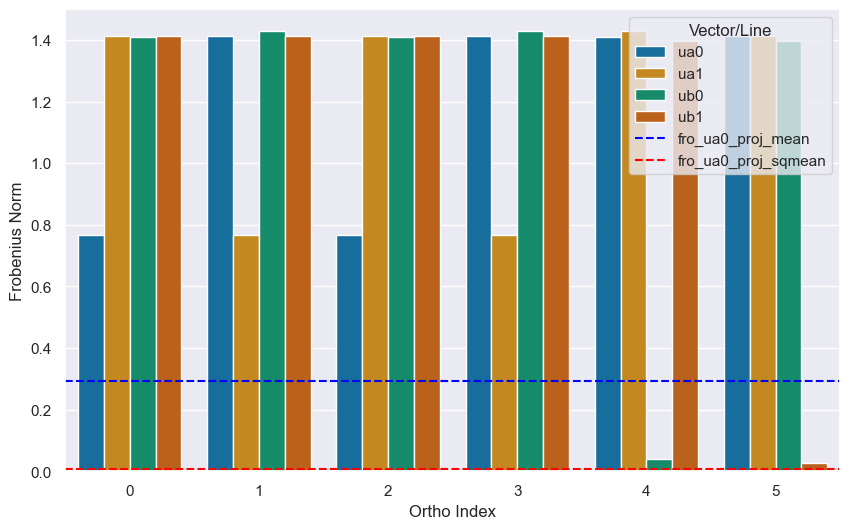

In [256]:
import seaborn as sns
import math
import matplotlib.pyplot as plt
import pandas as pd

sns.set_theme()
# use colorblind palette
sns.set_palette("colorblind")

fros_ua0 = [torch.linalg.norm(U[:, 0] - Uortho[:, i]).item() for i in range(Uortho.shape[1])]
fros_ua1 = [torch.linalg.norm(U[:, 1] - Uortho[:, i]).item() for i in range(Uortho.shape[1])]
fros_ub0 = [torch.linalg.norm(U[:, -2] - Uortho[:, i]).item() for i in range(Uortho.shape[1])]
fros_ub1 = [torch.linalg.norm(U[:, -1] - Uortho[:, i]).item() for i in range(Uortho.shape[1])]

ua0_proj = torch.stack([Uortho[:, i] for i in range(0, Uortho.shape[1]-Kb*Tb, 2)])
print(len(ua0_proj))
fro_ua0_proj_sqmean = torch.linalg.norm(U[:, 0] - (1/math.sqrt(Ka)) * ua0_proj.sum(dim=0)).item()
fro_ua0_proj_mean = torch.linalg.norm(U[:, 0] - (1/(Ka)) * ua0_proj.sum(dim=0)).item()

# Prepare data in longform for seaborn barplot
data = []
for idx in range(Uortho.shape[1]):
    data.append({'Ortho Index': idx, 'Vector': 'ua0', 'Frobenius Norm': fros_ua0[idx]})
    data.append({'Ortho Index': idx, 'Vector': 'ua1', 'Frobenius Norm': fros_ua1[idx]})
    data.append({'Ortho Index': idx, 'Vector': 'ub0', 'Frobenius Norm': fros_ub0[idx]})
    data.append({'Ortho Index': idx, 'Vector': 'ub1', 'Frobenius Norm': fros_ub1[idx]})
df = pd.DataFrame(data)

plt.figure(figsize=(10, 6))
sns.barplot(data=df, x="Ortho Index", y="Frobenius Norm", hue="Vector")
plt.xlabel("Ortho Index")
plt.ylabel("Frobenius Norm")
plt.legend(title="Vector")

# Add the two Frobenius distances as lines
plt.axhline(fro_ua0_proj_mean, color="blue", linestyle="--", label="fro_ua0_proj_mean")
plt.axhline(fro_ua0_proj_sqmean, color="red", linestyle="--", label="fro_ua0_proj_sqmean")


# Avoid duplicate legend for hue + lines
handles, labels = plt.gca().get_legend_handles_labels()
from collections import OrderedDict
by_label = OrderedDict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), title="Vector/Line")

plt.show()

In [257]:
# Check distance between ua @ sa @ vta and \sum_k uortho_k @ sortho_k @ vtortho_k

# w_a = ua @ sa @ vta
Uortho_a = Uortho[:, :Ka*Ta]
S_a = S[:Ka*Ta]
Vortho_a = Vortho[:, :Ka*Ta]
# Uortho_a.shape, S_a.shape, Vortho_a.shape
w_a_tsv = torch.einsum("ij,j,jk->ik", Uortho_a, S_a, Vortho_a.T)
w_a_wagt =  torch.einsum("ij,j,jk->ik", ua, sa, va.T)
w_a_wa = Ka*w_a_wagt

cos_a_tsv = cos_sim(w_a_tsv, w_a_wagt)
cos_a_wa = cos_sim(w_a_wa, w_a_wagt)

diff_a_tsv = torch.linalg.norm(w_a_tsv - w_a_wagt)
diff_a_wa = torch.linalg.norm(w_a_wa - w_a_wagt)

# Now for b
Uortho_b = Uortho[:, Ka*Ta:]
S_b = S[Ka*Ta:]
Vortho_b = Vortho[:, Ka*Ta:]
# Uortho_a.shape, S_a.shape, Vortho_a.shape
w_b_tsv = torch.einsum("ij,j,jk->ik", Uortho_b, S_b, Vortho_b.T)
w_b_wagt =  torch.einsum("ij,j,jk->ik", ub, sb, vb.T)
w_b_wa = Kb*w_b_wagt

cos_b_tsv = cos_sim(w_b_tsv, w_b_wagt)
cos_b_wa = cos_sim(w_b_wa, w_b_wagt)

diff_b_tsv = torch.linalg.norm(w_b_tsv - w_b_wagt)
diff_b_wa = torch.linalg.norm(w_b_wa - w_b_wagt)

# print(f"A: ‖tsv - wa‖ = {diff_a_tsv:.6f}, ‖wa - wagt‖ = {diff_a_wa:.6f}, intf_wa = {intf_a_wa:.6f}, intf_tsv = {intf_a_tsv:.6f}")
# print(f"B: ‖tsv - wa‖ = {diff_b_tsv:.6f}, ‖wa - wagt‖ = {diff_b_wa:.6f}, intf_wa = {intf_b_wa:.6f}, intf_tsv = {intf_b_tsv:.6f}")


# Create merges
# w_tsv = torch.einsum("ij,j,jk->ik", Uortho, S, Vortho.T)
w_tsv = 1/math.sqrt(Ka) * torch.einsum("ij,j,jk->ik", Uortho_a, S_a, Vortho_a.T) + 1/math.sqrt(Kb) * torch.einsum("ij,j,jk->ik", Uortho_b, S_b, Vortho_b.T)
w_wa = 1/(Ka*Kb) * torch.einsum("ij,j,jk->ik", U, S, V.T)
w_wagt = 0.5 * torch.einsum("ij,j,jk->ik", ua, sa, va.T) + 0.5 * torch.einsum("ij,j,jk->ik", ub, sb, vb.T)

# Nicer, informative printout of interference results
intf_tsv_wagt = interference(w_tsv, w_wagt)
intf_wa_wagt = interference(w_wa, w_wagt)
print(f"Interference between w_tsv and w_wagt: {intf_tsv_wagt:.6f}")
print(f"Interference between w_wa and w_wagt : {intf_wa_wagt:.6f}")

# intf_b_tsv = interference(w_b_tsv, w_wagt)
# intf_b_wa = interference(w_b_wa, w_wagt)

# intf_a_tsv = interference(w_a_tsv, w_wagt)
# intf_a_wa = interference(w_a_wa, w_wagt)


RuntimeError: einsum(): subscript j has size 2 for operand 2 which does not broadcast with previously seen size 4

In [289]:
# Uortho_a.shape, S_a.shape, Vortho.shape, Vortho_a.T.shape
# Uortho.shape, Vortho.shape

Uortho_a = Uortho[:, :Ka*Ta]
S_a = S[:Ka*Ta]
Vortho_a = Vortho[:, :Ka*Ta]
Uortho_b = Uortho[:, Ka*Ta:]
S_b = S[Ka*Ta:]
Vortho_b = Vortho[:, Ka*Ta:]


# Compare w_tsv to w_wagt
w_tsv_mean = torch.einsum("ij,j,jk->ik", Uortho, S, Vortho.T) * 1/Uortho.shape[1]
w_tsv_sqmean = 1/math.sqrt(Ka) * torch.einsum("ij,j,jk->ik", Uortho_a, S_a, Vortho_a.T) + 1/math.sqrt(Kb) * torch.einsum("ij,j,jk->ik", Uortho_b, S_b, Vortho_b.T)
w_wa = torch.einsum("ij,j,jk->ik", U, S, V.T) * 1/U.shape[1]
w_wagt = 0.5 * torch.einsum("ij,j,jk->ik", ua, sa, va.T) + 0.5 * torch.einsum("ij,j,jk->ik", ub, sb, vb.T)
intf_tsv_sqmean_wagt = interference(w_tsv_sqmean, w_wagt)
intf_tsv_mean_wagt = interference(w_tsv_mean, w_wagt)
intf_wa_wagt = interference(w_wa, w_wagt)

# Compare w_a_tsv to w_a_wagt
w_a_tsv_mean = torch.einsum("ij,j,jk->ik", Uortho_a, S_a, Vortho_a.T) * 1/Uortho_a.shape[1]
w_a_tsv_sqmean = 1/math.sqrt(Ka) * torch.einsum("ij,j,jk->ik", Uortho_a, S_a, Vortho_a.T)
w_a_wagt =  0.5 * torch.einsum("ij,j,jk->ik", ua, sa, va.T)
w_a_wa = Ka*w_a_wagt
intf_a_tsv_sqmean_wagt = interference(w_a_tsv_sqmean, w_a_wagt)
intf_a_tsv_mean_wagt = interference(w_a_tsv_mean, w_a_wagt)
intf_a_wa_wagt = interference(w_a_wa, w_a_wagt)


# Compare w_b_tsv to w_b_wagt
w_b_tsv_mean = torch.einsum("ij,j,jk->ik", Uortho_b, S_b, Vortho_b.T) * 1/Uortho_b.shape[1]
w_b_tsv_sqmean = 1/math.sqrt(Kb) * torch.einsum("ij,j,jk->ik", Uortho_b, S_b, Vortho_b.T)
w_b_wagt =  0.5 * torch.einsum("ij,j,jk->ik", ub, sb, vb.T)
w_b_wa = Kb*w_b_wagt
intf_b_tsv_sqmean_wagt = interference(w_b_tsv_sqmean, w_b_wagt)
intf_b_tsv_mean_wagt = interference(w_b_tsv_mean, w_b_wagt)
intf_b_wa_wagt = interference(w_b_wa, w_b_wagt)


import pandas as pd

# 1. Organize data into a dictionary
data = {
    "TSV (SqMean)": [intf_tsv_sqmean_wagt, intf_a_tsv_sqmean_wagt, intf_b_tsv_sqmean_wagt],
    "TSV (Mean)":   [intf_tsv_mean_wagt,   intf_a_tsv_mean_wagt,   intf_b_tsv_mean_wagt],
    "WA (Baseline)": [intf_wa_wagt,          intf_a_wa_wagt,          intf_b_wa_wagt]
}

# 2. Create DataFrame with descriptive row index
df_intf = pd.DataFrame(data, index=["Total Weight", "Weight A", "Weight B"])

# 3. Print with a clear title and formatting
print("\n=== INTERFERENCE COMPARISON ===")
print(df_intf.to_string(float_format=lambda x: f"{x:.6f}"))


# print(f"Interference between w_tsv_sqmean and w_wagt: {intf_tsv_sqmean_wagt:.6f}")
# print(f"Interference between w_tsv_mean and w_wagt : {intf_tsv_mean_wagt:.6f}")
# print(f"Interference between w_wa and w_wagt : {intf_wa_wagt:.6f}")

# print(f"Interference between w_a_tsv_sqmean and w_a_wagt: {intf_a_tsv_sqmean_wagt:.6f}")
# print(f"Interference between w_a_tsv_mean and w_a_wagt : {intf_a_tsv_mean_wagt:.6f}")
# print(f"Interference between w_a_wa and w_a_wagt : {intf_a_wa_wagt:.6f}")

# print(f"Interference between w_b_tsv_sqmean and w_b_wagt: {intf_b_tsv_sqmean_wagt:.6f}")
# print(f"Interference between w_b_tsv_mean and w_b_wagt : {intf_b_tsv_mean_wagt:.6f}")
# print(f"Interference between w_b_wa and w_b_wagt : {intf_b_wa_wagt:.6f}")


=== INTERFERENCE COMPARISON ===
              TSV (SqMean)  TSV (Mean)  WA (Baseline)
Total Weight      0.723188    0.427816       0.347982
Weight A          0.473931    0.239249       0.312626
Weight B          0.480723    0.027959       0.000000


In [282]:
# Uortho_a.shape, S_a.shape, Vortho.shape, Vortho_a.T.shape
# Uortho.shape, Vortho.shape

Uortho_a = Uortho[:, :Ka*Ta]
S_a = S[:Ka*Ta]
Vortho_a = Vortho[:, :Ka*Ta]
Uortho_b = Uortho[:, Ka*Ta:]
S_b = S[Ka*Ta:]
Vortho_b = Vortho[:, Ka*Ta:]

w_a_tsv_mean = torch.einsum("ij,j,jk->ik", Uortho_a, S_a, Vortho_a.T) * 1/Uortho_a.shape[1]
w_a_tsv_sqmean = 1/math.sqrt(Ka) * torch.einsum("ij,j,jk->ik", Uortho_a, S_a, Vortho_a.T)
w_a_wagt =  0.5 * torch.einsum("ij,j,jk->ik", ua, sa, va.T)
w_a_wa = Ka*w_a_wagt

# Printout of interference results
intf_tsv_sqmean_wagt = interference(w_a_tsv_sqmean, w_a_wagt)
intf_tsv_mean_wagt = interference(w_a_tsv_mean, w_a_wagt)
intf_wa_wagt = interference(w_a_wa, w_a_wagt)
print(f"Interference between w_tsv_sqmean and w_wagt: {intf_tsv_sqmean_wagt:.6f}")
print(f"Interference between w_tsv_mean and w_wagt : {intf_tsv_mean_wagt:.6f}")
print(f"Interference between w_wa and w_wagt : {intf_wa_wagt:.6f}")

Interference between w_tsv_sqmean and w_wagt: 0.767726
Interference between w_tsv_mean and w_wagt : 0.385526
Interference between w_wa and w_wagt : 0.500862


In [283]:
# Uortho_a.shape, S_a.shape, Vortho.shape, Vortho_a.T.shape
# Uortho.shape, Vortho.shape

Uortho_a = Uortho[:, :Ka*Ta]
S_a = S[:Ka*Ta]
Vortho_a = Vortho[:, :Ka*Ta]
Uortho_b = Uortho[:, Ka*Ta:]
S_b = S[Ka*Ta:]
Vortho_b = Vortho[:, Ka*Ta:]

w_b_tsv_mean = torch.einsum("ij,j,jk->ik", Uortho_b, S_b, Vortho_b.T) * 1/Uortho_b.shape[1]
w_b_tsv_sqmean = 1/math.sqrt(Kb) * torch.einsum("ij,j,jk->ik", Uortho_b, S_b, Vortho_b.T)
w_b_wagt =  0.5 * torch.einsum("ij,j,jk->ik", ub, sb, vb.T)
w_b_wa = Kb*w_b_wagt

# Printout of interference results
intf_tsv_sqmean_wagt = interference(w_b_tsv_sqmean, w_b_wagt)
intf_tsv_mean_wagt = interference(w_b_tsv_mean, w_b_wagt)
intf_wa_wagt = interference(w_b_wa, w_b_wagt)
print(f"Interference between w_tsv_sqmean and w_wagt: {intf_tsv_sqmean_wagt:.6f}")
print(f"Interference between w_tsv_mean and w_wagt : {intf_tsv_mean_wagt:.6f}")
print(f"Interference between w_wa and w_wagt : {intf_wa_wagt:.6f}")

Interference between w_tsv_sqmean and w_wagt: 1.174928
Interference between w_tsv_mean and w_wagt : 0.591940
Interference between w_wa and w_wagt : 0.759910


In [49]:
import torch
from tqdm import tqdm

batched_kron = torch.vmap(torch.kron)
def make_ls_mats(pus, pvs, a_tilde):
    """Create least squares params from task proj mats and target mat

    Args:
        pus (torch.Tensor): Task left proj mats. Shape: (B, Do, Do)
        pvs (torch.Tensor): Task right proj mats. Shape: (B, Di, Di)
        a_tilde (torch.Tensor): Target mat. Shape: (B, Do, Di)

    Returns:
        mis_stack (torch.Tensor): (B*D, D)
        a_tilde_flat (torch.Tensor): (B*D*D)
    """
    B, Do, Di = a_tilde.shape
    D = Do*Di
    mis = batched_kron(pvs, pus)
    a_tilde_flat = a_tilde.reshape(-1)  # (B*Do*Di)
    mis_stack = mis.reshape(-1, D)  # (B*D, D)
    return mis_stack, a_tilde_flat


def merge_avg(a_tilde):
    return a_tilde.mean(dim=0)


def compute_procrustes(x: torch.Tensor) -> torch.Tensor:
    """Finds best ortho approx of x

    Args:
        x (torch.Tensor): (Di, Do)

    Returns:
        torch.Tensor: (Di, Do)
    """
    u, _, vt = torch.linalg.svd(x, full_matrices=False)
    return u @ vt


def merge_tsv(tensors):
    """Computes the TSV merge of the given tensors.

    Args:
        tensors (torch.Tensor): The tensors to merge. Shape: (N_tasks, Di, Do)

    Returns:
        torch.Tensor: The merged tensors. Shape: (Di, Do)
    """
    N_tasks = len(tensors)
    u, s, vt = torch.linalg.svd(tensors, full_matrices=False)
    R = min(u.shape[1], vt.shape[2])
    Rp = R // N_tasks
    u, s, vt = u[:, :, :Rp], s[:, :Rp], vt[:, :Rp, :]

    # # # w/o decorrelation
    # tau_bl = torch.einsum("bij,bj,bjk->bik", u, s, vt)
    # tau[layer_name] = tau_bl.sum(dim=0)

    # w/ decorrelation
    B, Di, _ = u.shape
    _, _, Do = vt.shape
    # (Di, B, R)
    u_hat = u.permute(1, 0, 2).reshape(Di, B * Rp)
    s_hat = s.reshape(-1)
    vt_hat = vt.reshape(B * Rp, Do)
    u_ortho = compute_procrustes(u_hat)  # (Di, Rp)
    vt_ortho = compute_procrustes(vt_hat.T).T  # (Rp, Do)
    tau_l = torch.einsum("ij,j,jk->ik", u_ortho, s_hat, vt_ortho)
    return tau_l

def compute_lsopt_loss(a_hat, mis_stack, a_tilde_flat):
    pred = mis_stack @ a_hat.reshape(-1)
    loss = torch.nn.functional.mse_loss(pred, a_tilde_flat)  # default = mean
    return loss


def compute_lsopt_loss_gd(a_hat, a_tilde):
    """Computes the loss for the LSopt optimization.

    Args:
        a_hat (torch.Tensor): (Do, Di)
        a_tilde (torch.Tensor): (B, Do, Di)

    Returns:
        _type_: _description_
    """
    B, Do, Di = a_tilde.shape
    u, s, vt = torch.linalg.svd(a_tilde, full_matrices=False)
    R = min(u.shape[1], vt.shape[2])
    Rp = max(1, R // B)
    u = u[:, :, :Rp]
    vt = vt[:, :Rp, :]
    pus = u @ u.transpose(1, 2)  # (B, Do, Do)
    v = vt.transpose(1, 2)
    pvs = v @ vt  # (B, Di, Di)
    preds = torch.einsum("boj,jk,bki->boi", pus, a_hat, pvs)
    loss = torch.linalg.norm(preds - a_tilde, ord="fro", dim=(1, 2)).square().mean()
    return loss



def merge_lsopt_gd(a_tilde, verbose=False, max_iter=1000, tol=1e-8, lr=0.01):
    B, Do, Di = a_tilde.shape
    device = a_tilde.device

    # mis_stack, a_tilde_flat = make_ls_mats(pus, pvs, a_tilde)
    a_hat = torch.nn.Parameter(torch.randn(Do, Di, device=device, dtype=a_tilde.dtype))
    opt = torch.optim.AdamW([a_hat], lr=lr)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt, "min", patience=10, factor=0.1
    )

    loss_prev = float("inf")
    for it in tqdm(range(max_iter), desc="LSopt GD", leave=False):
        opt.zero_grad()
        # pred = mis_stack @ a_hat.reshape(-1)
        # loss = torch.nn.functional.mse_loss(pred, a_tilde_flat)  # default = mean
        # loss = compute_lsopt_loss(a_hat, mis_stack, a_tilde_flat)
        loss = compute_lsopt_loss_gd(a_hat, a_tilde)

        loss.backward()
        opt.step()
        sched.step(loss.item())

        lv = loss.item()
        if verbose:
            print(f"iter {it}, loss {lv}")

        if abs(lv - loss_prev) < tol:
            if verbose:
                print(f"Converged in {it} iterations")
            break
        loss_prev = lv

    return a_hat.detach()



def merge_lsopt(a_tilde, verbose=False):
    """
    Args:
        a_tilde (torch.Tensor): Task matrices. Shape: (B, Do, Di)
        verbose (bool): Whether to print debug info

    Returns:
        a_hat (torch.Tensor): Merged task matrix. Shape: (Do, Di)
    """
    # B, Do, Di = 8, 32, 64
    # a_tilde = torch.randn(B, Do, Di)
    B, Do, Di = a_tilde.shape
    u, s, vt = torch.linalg.svd(a_tilde, full_matrices=False)
    # truncate
    R = min(u.shape[1], vt.shape[2])
    Rp = R // len(a_tilde)
    u = u[:, :, :Rp]
    vt = vt[:, :Rp, :]

    ut = u.permute(0, 2, 1)
    v = vt.permute(0, 2, 1)
    pus = torch.einsum('bij,bjk->bik', u, ut)
    pvs = torch.einsum('bij,bjk->bik', v, vt)

    mis_stack, a_tilde_flat = make_ls_mats(pus, pvs, a_tilde)
    if verbose:
        print('pus.shape', pus.shape)
        print('pvs.shape', pvs.shape)
        print('batched_kron.shape', batched_kron(pus, pvs).shape)
        print('mis_stack.shape', mis_stack.shape)
        print('a_tilde_flat.shape', a_tilde_flat.shape)

    print("Computing LS solution...")
    sol = torch.linalg.lstsq(mis_stack, a_tilde_flat)
    print("Done.")
    a_hat_vec = sol.solution
    a_hat = a_hat_vec.reshape(Do, Di)
    return a_hat

def compute_tsvopt_loss(u_ortho, s_hat, vt_ortho, a_tilde):
    """Computes the loss for the TSV optimization.

    Args:
        u_ortho (torch.Tensor): (Di, Rp)
        vt_ortho (torch.Tensor): (Rp, Do)
        a_tilde (torch.Tensor): (B, Do, Di)

    Returns:
        _type_: _description_
    """
    pred = torch.einsum("ij,j,jk->ik", u_ortho, s_hat, vt_ortho)  # (Di, Do)
    loss = (
        torch.linalg.norm(pred.unsqueeze(0) - a_tilde, ord="fro", dim=(1, 2))
        .square()
        .mean()
    )  # (B, Do, Di)
    return loss

def merge_tsvopt(a_tilde, verbose=False, n_iters=100, *args, **kwargs):
    N_tasks = len(a_tilde)
    u, s, vt = torch.linalg.svd(a_tilde, full_matrices=False)
    R = min(u.shape[1], vt.shape[2])
    Rp = R // N_tasks
    u, s, vt = u[:, :, :Rp], s[:, :Rp], vt[:, :Rp, :]

    # w/ decorrelation
    B, Di, _ = u.shape
    _, _, Do = vt.shape
    # (Di, B, R)
    u_hat = u.permute(1, 0, 2).reshape(Di, B * Rp)
    # s_hat = s.reshape(-1)
    vt_hat = vt.reshape(B * Rp, Do)
    u_ortho = compute_procrustes(u_hat)  # (Di, Rp)
    vt_ortho = compute_procrustes(vt_hat.T).T  # (Rp, Do)

    # Get optimal singular values
    s_hat = torch.nn.Parameter(s.reshape(-1).clone())
    opt = torch.optim.AdamW([s_hat], lr=0.01)
    for t in range(n_iters):
        opt.zero_grad()
        loss = compute_tsvopt_loss(u_ortho, s_hat, vt_ortho, a_tilde)
        loss.backward()
        opt.step()
    return torch.einsum("ij,j,jk->ik", u_ortho, s_hat, vt_ortho)

B, Do, Di = 8, 32, 64
a_tilde = torch.randn(B, Do, Di)
# a_hat_1 = merge_lsopt(a_tilde)
a_hat_2 = merge_lsopt_gd(a_tilde, max_iter=1000, tol=1e-8, verbose=False)
# a_hat_3 = merge_tsvopt(a_tilde, n_iters=100)
print(a_hat_2.shape)
# print("Allclose?", torch.allclose(a_hat_1, a_hat_2, atol=1e-4))
# >>> torch.allclose(a_hat_1, a_hat_2, atol=1e-5)
# False

torch.Size([32, 64])


In [44]:
# B, Do, Di = 8, 32, 64
# a_tilde = torch.randn(B, Do, Di)
B, Do, Di = a_tilde.shape
u, s, vt = torch.linalg.svd(a_tilde, full_matrices=False)
# truncate
R = min(u.shape[1], vt.shape[2])
Rp = R // len(a_tilde)
u = u[:, :, :Rp]
vt = vt[:, :Rp, :]

ut = u.permute(0, 2, 1)
v = vt.permute(0, 2, 1)
pus = torch.einsum('bij,bjk->bik', u, ut)
pvs = torch.einsum('bij,bjk->bik', v, vt)

mis_stack, a_tilde_flat = make_ls_mats(pus, pvs, a_tilde)

loss_rand = compute_lsopt_loss(torch.randn(Do, Di), mis_stack, a_tilde_flat)
loss_lsopt = compute_lsopt_loss(a_hat_1, mis_stack, a_tilde_flat)
loss_lsopt_gd = compute_lsopt_loss(a_hat_2, mis_stack, a_tilde_flat)

print("Loss rand", loss_rand.item())
print("Loss lsopt", loss_lsopt.item())
print("Loss lsopt_gd", loss_lsopt_gd.item())


Loss rand 1.0221692323684692
Loss lsopt 1.0026545524597168
Loss lsopt_gd 1.0294201374053955


Computing LS solution...
Done.


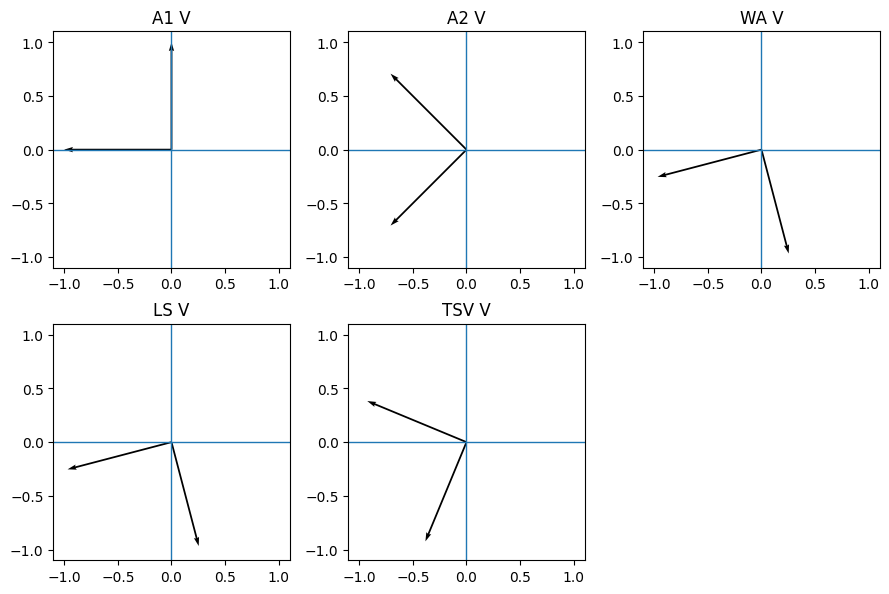

In [ ]:
import matplotlib.pyplot as plt
import math
# ----------------------------
# Toy with tunable orthogonality
# ----------------------------
ortho = 0.5                 # 0 = aligned, 1 = orthogonal
theta_v = ortho * (math.pi/2)

B, Do, Di = 2, 2, 2

v1 = torch.tensor([1.0, 0.0])
v2 = torch.tensor([math.cos(theta_v), math.sin(theta_v)])

u1 = torch.tensor([1.0, 1.0]);  u1 = u1 / u1.norm()
u2 = torch.tensor([1.0, -1.0]); u2 = u2 / u2.norm()

s1, s2 = 2.0, 1.5
A1 = s1 * torch.outer(u1, v1)
A2 = s2 * torch.outer(u2, v2)
a_tilde = torch.stack([A1, A2], dim=0)

A_wa  = merge_avg(a_tilde)
A_ls  = merge_lsopt(a_tilde)
A_tsv = merge_tsv(a_tilde)


# ----------------------------
# Plot right singular vectors
# ----------------------------
def right_singular_vecs(A):
    _, _, Vt = torch.linalg.svd(A, full_matrices=False)
    return Vt.T

def plot_right_vecs(ax, A, title):
    V = right_singular_vecs(A)
    ax.axhline(0, linewidth=1); ax.axvline(0, linewidth=1)
    ax.quiver([0,0], [0,0], V[0,:], V[1,:],
              angles='xy', scale_units='xy', scale=1)
    ax.set_aspect('equal', 'box')
    ax.set_xlim(-1.1, 1.1); ax.set_ylim(-1.1, 1.1)
    ax.set_title(title)

fig, axs = plt.subplots(2, 3, figsize=(9, 6))
plot_right_vecs(axs[0,0], A1,  "A1 V")
plot_right_vecs(axs[0,1], A2,  "A2 V")
plot_right_vecs(axs[0,2], A_wa,"WA V")
plot_right_vecs(axs[1,0], A_ls,"LS V")
plot_right_vecs(axs[1,1], A_tsv,"TSV V")
axs[1,2].axis("off")
plt.tight_layout()
plt.show()

### Geometric interpretation of TSV

/var/folders/r_/d81gvkws1n5fg2_7mb57cwzh0000gn/T/ipykernel_56485/1681312568.py:95: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  Y = A @ X_unit_sphere


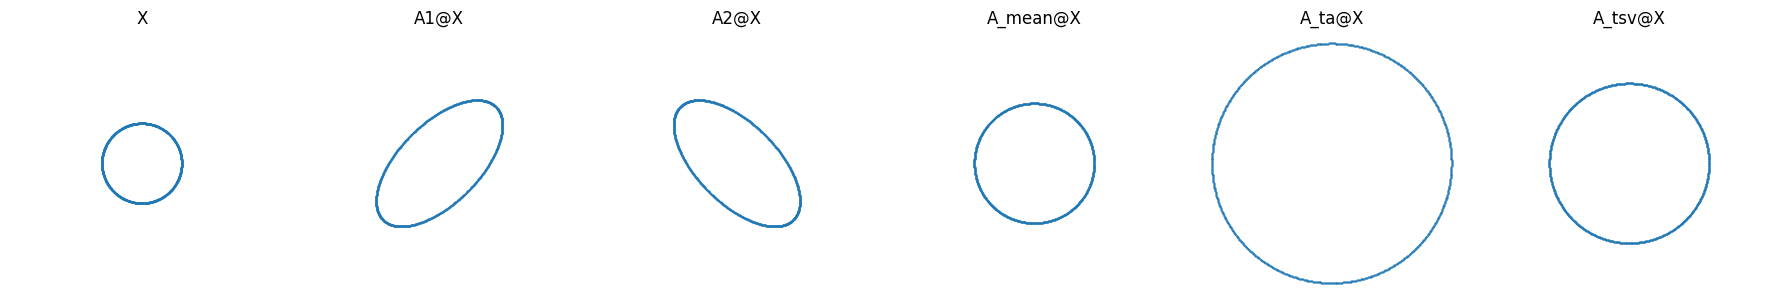

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch

def rot(deg):
    t = np.deg2rad(deg)
    c, s = np.cos(t), np.sin(t)
    return np.array([[c, -s], [s, c]])

def merge_mean(As):
    return sum(As) / len(As)

def merge_ta(As):
    return sum(As)

def compute_procrustes(x: torch.Tensor) -> torch.Tensor:
    """Finds best ortho approx of x

    Args:
        x (torch.Tensor): (Di, Do)

    Returns:
        torch.Tensor: (Di, Do)
    """
    u, _, vt = torch.linalg.svd(x, full_matrices=False)
    return u @ vt

def get_tsv_merge(tensors):
    """Computes the TSV merge of the given tensors.

    Args:
        tensors (torch.Tensor): The tensors to merge. Shape: (N_tasks, Di, Do)

    Returns:
        torch.Tensor: The merged tensors. Shape: (Di, Do)
    """
    N_tasks = len(tensors)
    u, s, vt = torch.linalg.svd(tensors, full_matrices=False)
    R = min(u.shape[1], vt.shape[2])
    Rp = R // N_tasks
    u, s, vt = u[:, :, :Rp], s[:, :Rp], vt[:, :Rp, :]

    # # # w/o decorrelation
    # tau_bl = torch.einsum("bij,bj,bjk->bik", u, s, vt)
    # tau[layer_name] = tau_bl.sum(dim=0)

    # w/ decorrelation
    B, Di, _ = u.shape
    _, _, Do = vt.shape
    # (Di, B, R)
    u_hat = u.permute(1, 0, 2).reshape(Di, B * Rp)
    s_hat = s.reshape(-1)
    vt_hat = vt.reshape(B * Rp, Do)
    u_ortho = compute_procrustes(u_hat)  # (Di, Rp)
    vt_ortho = compute_procrustes(vt_hat.T).T  # (Rp, Do)
    tau_l = torch.einsum("ij,j,jk->ik", u_ortho, s_hat, vt_ortho)
    return tau_l

def merge_tsv(As, r=1):
    # U = np.concatenate([np.linalg.svd(A, full_matrices=False)[0][:, :r] for A in As], axis=1)
    # V = np.concatenate([np.linalg.svd(A, full_matrices=False)[2].T[:, :r] for A in As], axis=1)
    # U, _ = np.linalg.qr(U)
    # V, _ = np.linalg.qr(V)
    # Abar = merge_mean(As)
    # B = U.T @ Abar @ V
    # Ub, s, Vhb = np.linalg.svd(B, full_matrices=False)
    # return U @ (Ub * s) @ Vhb @ V.T
    return get_tsv_merge(torch.stack([torch.from_numpy(A) for A in As]))


# data on unit circle
tvs = np.linspace(0, 2*np.pi, 800, endpoint=False)
X_unit_sphere = np.stack([np.cos(tvs), np.sin(tvs)])

R1, R2 = rot(45), rot(-45)
S = np.diag([2.0, 1.0])
A1 = R1 @ S @ R1.T
A2 = R2 @ S @ R2.T

A_mean = merge_mean([A1, A2])
A_ta = merge_ta([A1, A2])
A_tsv  = merge_tsv([A1, A2], r=1)

mats = [
    ("X", np.eye(2)),
    ("A1@X", A1),
    ("A2@X", A2),
    ("A_mean@X", A_mean),
    ("A_ta@X", A_ta),
    ("A_tsv@X", A_tsv),
]

fig, ax = plt.subplots(1, len(mats), figsize=(3*len(mats), 3), sharex=True, sharey=True)
for a, (title, A) in zip(ax, mats):
    Y = A @ X_unit_sphere
    a.plot(Y[0], Y[1], ".", ms=1)
    a.set_title(title); a.set_aspect("equal"); a.axis("off")
plt.tight_layout(); plt.show()


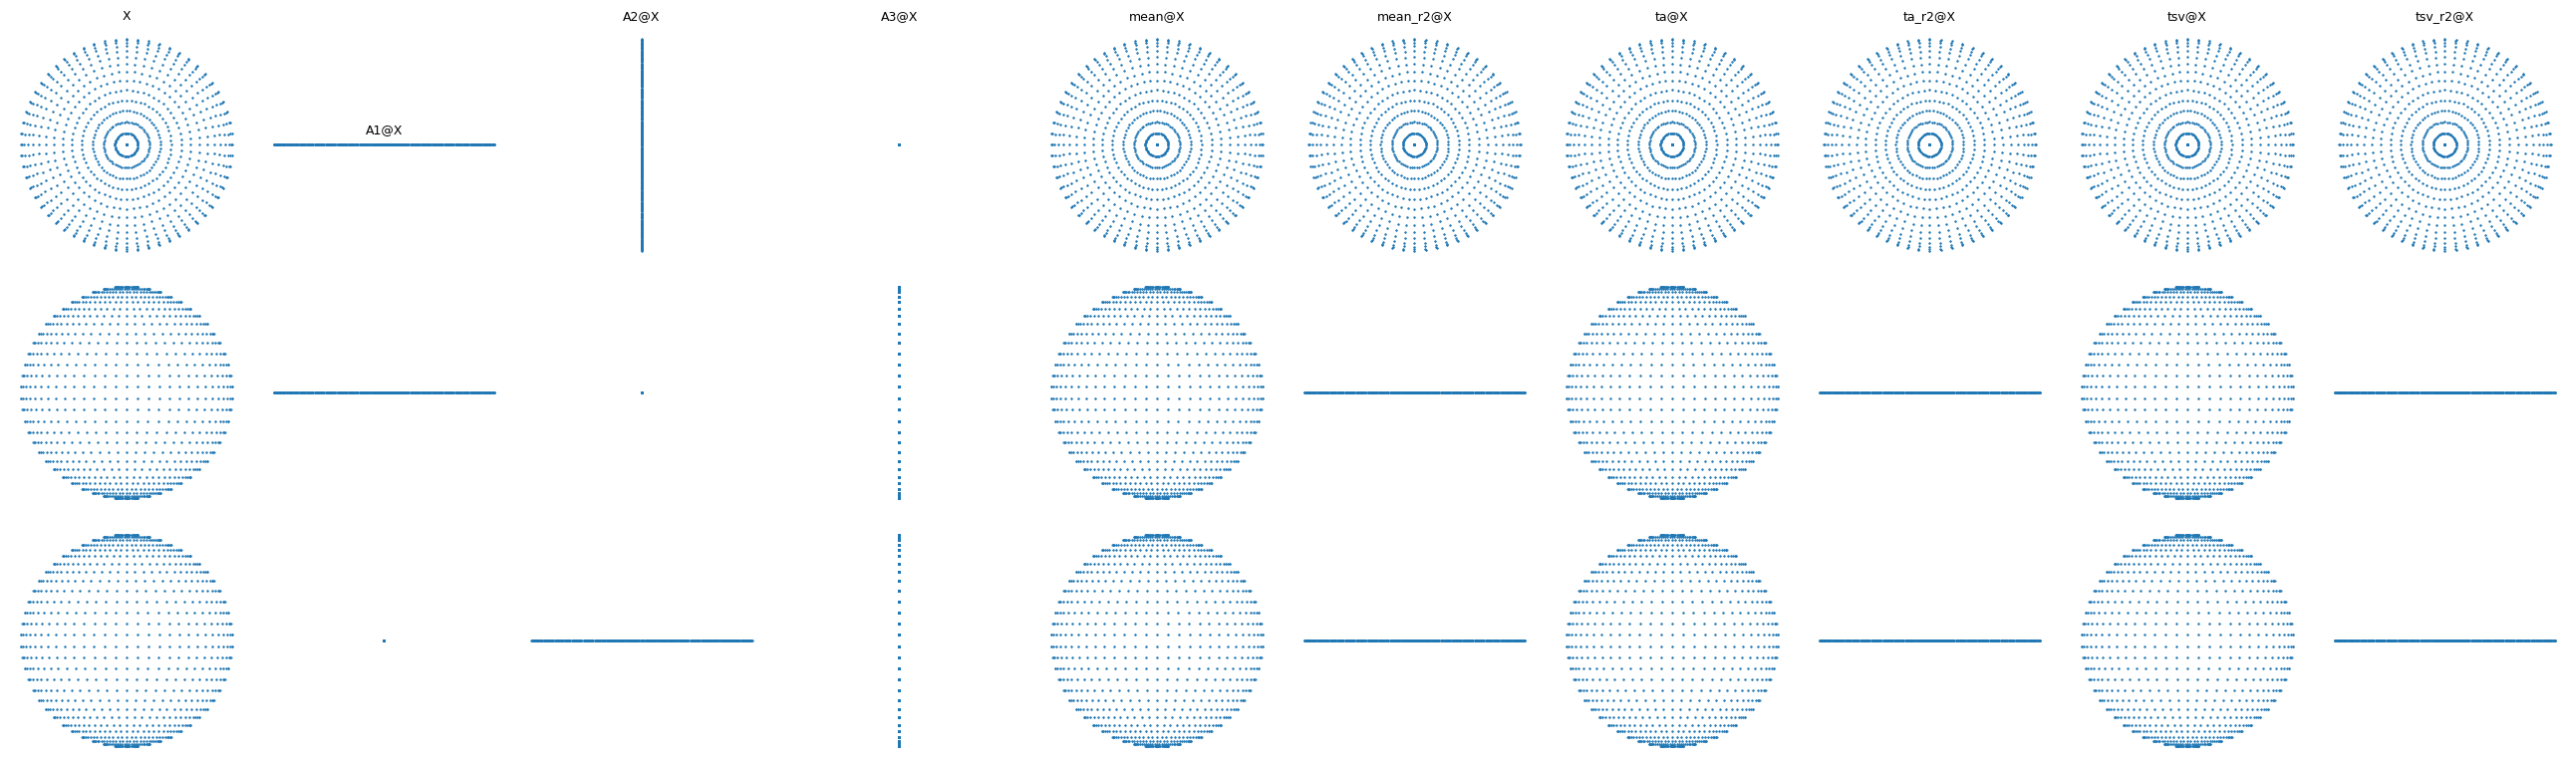

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch

def merge_mean(As):
    return sum(As) / len(As)

def merge_ta(As):
    return sum(As)

def best_rank_k_np(A, k):
    U, s, Vt = np.linalg.svd(A, full_matrices=False)
    return U[:, :k] @ np.diag(s[:k]) @ Vt[:k, :]

def compute_procrustes(x: torch.Tensor) -> torch.Tensor:
    u, _, vt = torch.linalg.svd(x, full_matrices=False)
    return u @ vt

def get_tsv_merge(tensors):
    N_tasks = len(tensors)
    u, s, vt = torch.linalg.svd(tensors, full_matrices=False)
    R = min(u.shape[1], vt.shape[2])
    Rp = R // N_tasks  # rank per task (with full SVD this becomes 1 in 3-task, 3D case)
    u, s, vt = u[:, :, :Rp], s[:, :Rp], vt[:, :Rp, :]

    B, Di, _ = u.shape
    _, _, Do = vt.shape
    u_hat = u.permute(1, 0, 2).reshape(Di, B * Rp)
    s_hat = s.reshape(-1)
    vt_hat = vt.reshape(B * Rp, Do)

    u_ortho = compute_procrustes(u_hat)
    vt_ortho = compute_procrustes(vt_hat.T).T
    tau_l = torch.einsum("ij,j,jk->ik", u_ortho, s_hat, vt_ortho)
    return tau_l

def merge_tsv(As):
    return get_tsv_merge(torch.stack([torch.from_numpy(A).float() for A in As])).numpy()


# =========================
# 🔥 MINIMAL “AHA” CHANGES:
# 1) go to 3D
# 2) use 3 rank-1 “tasks” on different axes
# 3) enforce a rank budget after merging (rank-2)
# 4) visualize via 2D projections (xy, xz, yz)
# =========================

# data on unit sphere in 3D
phi = np.linspace(0, 2*np.pi, 60, endpoint=False)
theta_v = np.linspace(0, np.pi, 30, endpoint=True)
phi, theta_v = np.meshgrid(phi, theta_v)
X_unit_sphere = np.stack([
    np.sin(theta_v) * np.cos(phi),
    np.sin(theta_v) * np.sin(phi),
    np.cos(theta_v),
]).reshape(3, -1)

# three rank-1-ish maps, orthogonal directions
A1 = np.diag([2.0, 0.0, 0.0])  # stretch x
A2 = np.diag([0.0, 2.0, 0.0])  # stretch y
A3 = np.diag([0.0, 0.0, 2.0])  # stretch z
As = [A1, A2, A3]

A_mean = merge_mean(As)
A_ta   = merge_ta(As)
A_tsv  = merge_tsv(As)

# enforce the same rank budget (this is where WA vs TSV diverge)
k = 2
A_mean_k = best_rank_k_np(A_mean, k)
A_ta_k   = best_rank_k_np(A_ta, k)
A_tsv_k  = best_rank_k_np(A_tsv, k)

mats = [
    ("X", np.eye(3)),
    ("A1@X", A1),
    ("A2@X", A2),
    ("A3@X", A3),

    ("mean@X", A_mean),
    (f"mean_r{k}@X", A_mean_k),

    ("ta@X", A_ta),
    (f"ta_r{k}@X", A_ta_k),

    ("tsv@X", A_tsv),
    (f"tsv_r{k}@X", A_tsv_k),
]

# plot 2D projections: xy, xz, yz
projs = [("xy", (0, 1)), ("xz", (0, 2)), ("yz", (1, 2))]

fig, ax = plt.subplots(
    len(projs), len(mats),
    figsize=(2.6 * len(mats), 2.6 * len(projs)),
    sharex=False, sharey=False
)

for r, (pname, (i, j)) in enumerate(projs):
    for c, (title, A) in enumerate(mats):
        Y = A @ X_unit_sphere
        ax[r, c].plot(Y[i], Y[j], ".", ms=1)
        if r == 0:
            ax[r, c].set_title(title, fontsize=9)
        if c == 0:
            ax[r, c].set_ylabel(pname, rotation=0, labelpad=12, fontsize=10)
        ax[r, c].set_aspect("equal")
        ax[r, c].axis("off")

plt.tight_layout()
plt.show()


### OPT

In [ ]:
import os
import json
from typing import List
import numpy as np
import torch

os.environ["OPENCLIP_CACHEDIR"] = os.environ["SCRATCH"] + "/openclip"


import matplotlib.pyplot as plt
from src.models.task_vectors import NonLinearTaskVector


MODELS_ROOT = os.path.expanduser("models/checkpoints")
# datasets = ["Cars", "DTD", "EuroSAT", "GTSRB", "MNIST", "RESISC45", "SUN397", "SVHN"]
datasets = ["Cars", "DTD", "EuroSAT", "GTSRB", "MNIST", "SVHN"]
model = "ViT-B-16"
device = "cuda:0"

# Calculate task vectors
task_vectors = []
pretrained_checkpoint = f"{MODELS_ROOT}/{model}/MNISTVal/nonlinear_zeroshot.pt"
for dataset in datasets:
    finetuned_checkpoint = f"{MODELS_ROOT}/{model}/{dataset}Val/nonlinear_finetuned.pt"
    task_vectors.append(
        NonLinearTaskVector(model, pretrained_checkpoint, finetuned_checkpoint)
    )

In [ ]:
# Pull out single matrix
mats = []

for key in task_vectors[0].vector:
    if len(task_vectors[0].vector[key].shape) == 2 and "text_projection" not in key:
        if task_vectors[0].vector[key].min() == task_vectors[0].vector[key].max() == 0:
            continue
        for tv in task_vectors:
            mats.append(tv.vector[key])
        break

mats = torch.stack(mats)

In [ ]:
# Save the mats
torch.save(mats, "results/mats.pt")

In [16]:
import torch
# Load the mats
mats = torch.load("results/mats.pt")
print(mats.shape), mats.min(), mats.max()


torch.Size([6, 197, 768])


(None, tensor(-0.0014), tensor(0.0015))

In [32]:
import numpy as np
def calc_rank(S, norm_thresh=0.95):
    # Rank based on approximation error (Eq. 6) in the paper
    rank = np.argmax(np.sqrt(np.cumsum(S.pow(2) / S.pow(2).sum())) > norm_thresh)
    return rank

def compute_sar(u, s, mats):

    # figure out effective rank
    rank_eff = calc_rank(s)
    u = u[:, :rank_eff]

    proj_m_w = torch.einsum("ij,jk,bkl->bil", u, u.T, mats)
    return torch.linalg.norm(proj_m_w, ord="fro", dim=(1, 2)) / torch.linalg.norm(mats, ord="fro", dim=(1, 2))  # (b,)


def compute_delta_m_sum(mats):
    delta_m = torch.sum(mats, dim=0)
    u, s, vt = torch.linalg.svd(delta_m, full_matrices=False)
    return delta_m, u, s

def compute_delta_m_iso(mats):
    delta_m = torch.sum(mats, dim=0)
    u, s, vt = torch.linalg.svd(delta_m, full_matrices=False)
    s_mean = torch.ones_like(s) * s.mean()
    return torch.einsum("ij,j,jk->ik", u, s_mean, vt), u, s

def compute_delta_m_opt(mats):
    delta_t_outers = torch.einsum("bik,bkj->bij", mats, mats.permute(0, 2, 1))
    delta_t_frobs = torch.linalg.norm(mats, ord="fro", dim=(1, 2))[
        :, None, None
    ]
    mat_a = (delta_t_outers / delta_t_frobs).sum(dim=0)
    lam, u = torch.linalg.eig(mat_a)
    return None, u, torch.ones_like(lam)

methods = [
    ("sum", compute_delta_m_sum),
    ("iso", compute_delta_m_iso),
    ("opt", compute_delta_m_opt),
]

rows = []
for method_name, method_fn in methods:
    delta_m, u, s = method_fn(mats)
    sar_m = compute_sar(u, s, mats)
    rows.append({"method": method_name, "sar": sar_m})

/var/folders/r_/d81gvkws1n5fg2_7mb57cwzh0000gn/T/ipykernel_36156/1199381627.py:4: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  rank = np.argmax(np.sqrt(np.cumsum(S.pow(2) / S.pow(2).sum())) > norm_thresh)


NotImplementedError: "gt_cpu" not implemented for 'ComplexFloat'

In [28]:
rows

[{'method': 'sum',
  'sar': tensor([0.7909, 0.8007, 0.8295, 0.8179, 0.8240, 0.8547])},
 {'method': 'iso',
  'sar': tensor([0.9549, 0.9521, 0.9563, 0.9526, 0.9525, 0.9568])}]